# Stochastic CTMC Models

This notebook demonstrates the **stochastic** epidemic models in epimodels, based on **Continuous-Time Markov Chains (CTMCs)** solved via the Gillespie Stochastic Simulation Algorithm (SSA).

Unlike deterministic ODE models, stochastic models capture the inherent randomness in epidemic dynamics, which is especially important for small populations or when quantifying extinction risk.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown as md
from epimodels.stochastic.CTMC import SIR, SIS, SIRS, SEIR, GillespieSolver

## 1. Running a Single Replicate

The stochastic SIR model follows the same calling convention as deterministic models, with additional parameters `reps` and `seed`.

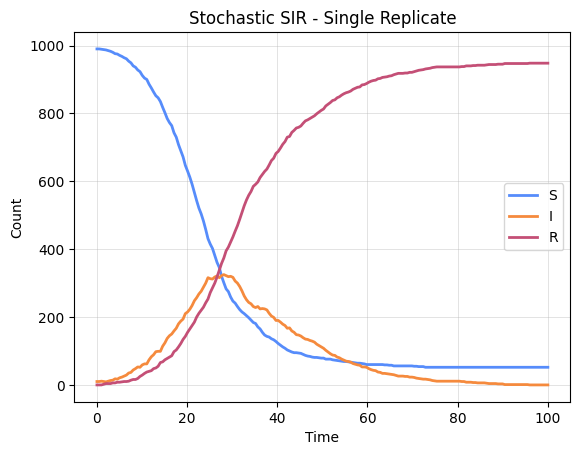

In [2]:
model = SIR()
model(
    inits=[990, 10, 0],
    trange=[0, 100],
    totpop=1000,
    params={'beta': 0.3, 'gamma': 0.1},
    reps=1,
    seed=42,
    n_points=200,
)

model.plot_traces()
plt.title('Stochastic SIR - Single Replicate')
plt.show()

## 2. Multiple Replicates and Uncertainty Quantification

The real power of stochastic models lies in running many replicates to characterize the distribution of possible epidemic trajectories. The `plot_traces` method can show the mean with confidence interval bands.

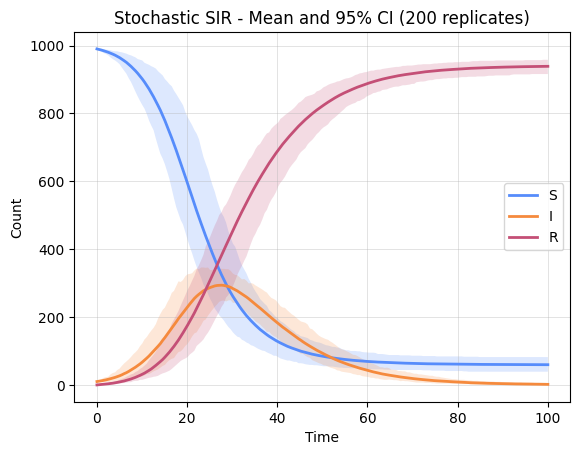

In [3]:
model = SIR()
model(
    inits=[990, 10, 0],
    trange=[0, 100],
    totpop=1000,
    params={'beta': 0.3, 'gamma': 0.1},
    reps=200,
    seed=42,
    n_points=200,
)

model.plot_traces(show_ci=True, ci=0.95)
plt.title('Stochastic SIR - Mean and 95% CI (200 replicates)')
plt.show()

### Individual Replicates

You can also visualize individual trajectories to see the stochastic variability.

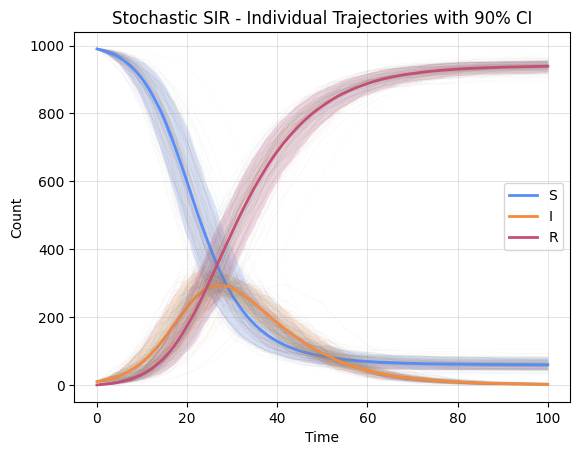

In [4]:
model.plot_traces(show_reps=True, alpha=0.05, show_ci=True, ci=0.90)
plt.title('Stochastic SIR - Individual Trajectories with 90% CI')
plt.show()

## 3. Accessing Results

The `traces` dict stores all replicate data. For multi-replicate runs, each variable is a 2D array of shape `(reps, n_points)`. Use accessor methods to get statistics.

In [5]:
# Shape of traces for multi-replicate run
print('S shape:', model.traces['S'].shape)
print('I shape:', model.traces['I'].shape)
print('time shape:', model.traces['time'].shape)

# Get mean trajectory
mean = model.get_mean()
print(f'\nMean peak I: {mean["I"].max():.1f}')
print(f'Mean final R: {mean["R"][-1]:.1f}')

S shape: (200, 200)
I shape: (200, 200)
time shape: (200,)

Mean peak I: 293.9
Mean final R: 938.8


## 4. Summary Statistics

The `summary()` method returns epidemic statistics with stochastic extensions including extinction probability and confidence intervals on peak infections.

In [6]:
stats = model.summary()
for k, v in stats.items():
    print(f'{k}: {v}')

model: SIR CTMC
t_start: 0.0
t_end: 100.0
reps: 200
peak_I_mean: 293.885
peak_time_mean: 27.63819095477387
final_S_mean: 59.565
final_R_mean: 938.775
attack_rate_mean: 0.9398333333333333
extinction_probability: 0.28
peak_I_median: 309.5
peak_I_ci: (271.975, 354.025)


## 5. Quantiles and Variance

Compute quantile trajectories to construct custom confidence bands.

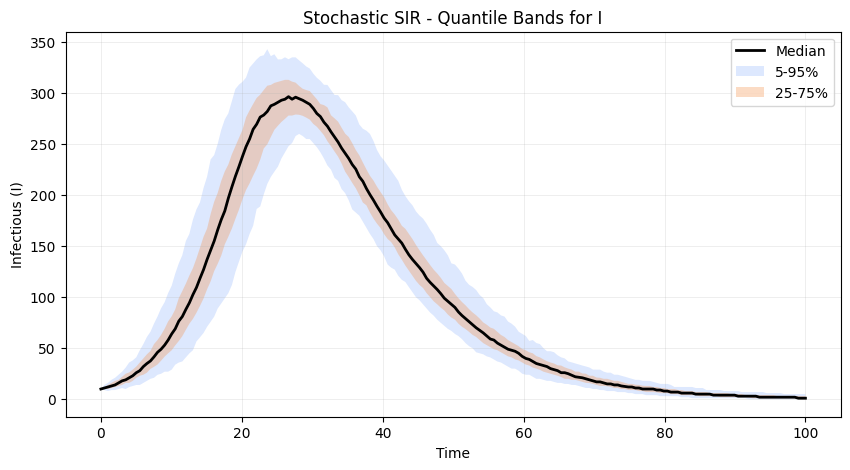

In [7]:
quantiles = model.get_quantiles([0.05, 0.25, 0.5, 0.75, 0.95])

time = model.traces['time']
plt.figure(figsize=(10, 5))

# Plot median
plt.plot(time, quantiles[0.5]['I'], 'k-', linewidth=2, label='Median')

# Plot quantile bands
plt.fill_between(time, quantiles[0.05]['I'], quantiles[0.95]['I'],
                 alpha=0.2, label='5-95%')
plt.fill_between(time, quantiles[0.25]['I'], quantiles[0.75]['I'],
                 alpha=0.3, label='25-75%')

plt.xlabel('Time')
plt.ylabel('Infectious (I)')
plt.title('Stochastic SIR - Quantile Bands for I')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Event Tracking

CTMC models track individual events (infections, recoveries, etc.). You can access event occurrence times across all replicates.

infection: 186087 occurrences
recovery: 187755 occurrences


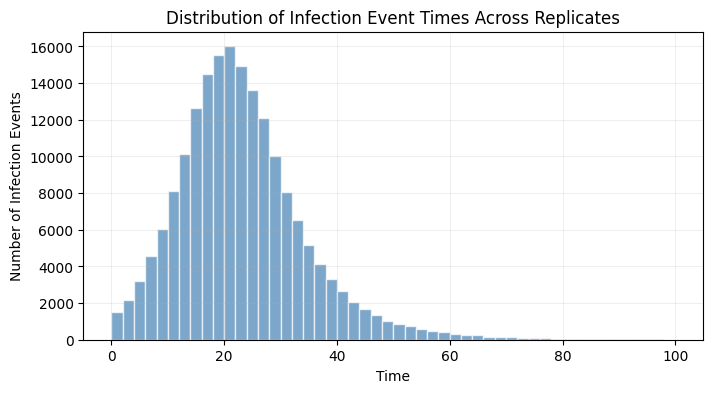

In [8]:
event_times = model.get_event_times()
for event_name, times in event_times.items():
    print(f'{event_name}: {len(times)} occurrences')

# Plot histogram of infection event times
infection_times = model.get_event_times('infection')
plt.figure(figsize=(8, 4))
plt.hist(infection_times, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
plt.xlabel('Time')
plt.ylabel('Number of Infection Events')
plt.title('Distribution of Infection Event Times Across Replicates')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Comparison with Deterministic ODE Model

For large populations, the stochastic mean converges toward the deterministic ODE solution. For small populations, the stochastic model reveals additional dynamics like extinction.

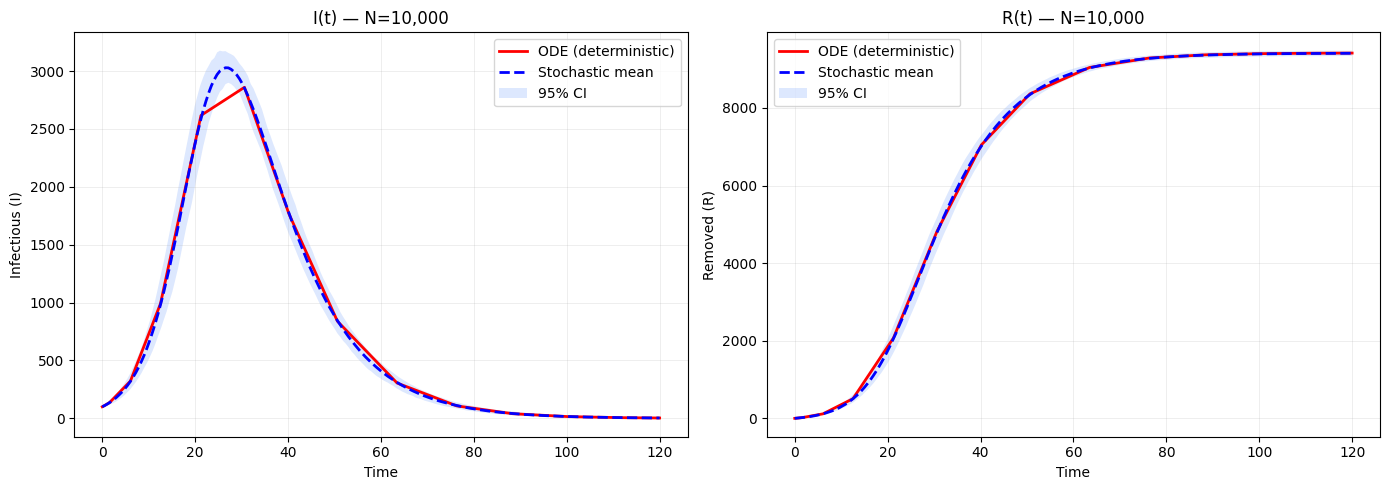

In [9]:
from epimodels.continuous import SIR as ODE_SIR

# Large population comparison
N = 10000
I0 = 100
params = {'beta': 0.3, 'gamma': 0.1}

# Deterministic ODE
ode = ODE_SIR()
ode([N - I0, I0, 0], [0, 120], N, params)

# Stochastic CTMC (300 replicates)
sto = SIR()
sto([N - I0, I0, 0], [0, 120], N, params, reps=300, seed=42, n_points=200)

# Compare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: I comparison
sto_mean = sto.get_mean()
axes[0].plot(ode.traces['time'], ode.traces['I'], 'r-', linewidth=2, label='ODE (deterministic)')
axes[0].plot(sto_mean['time'], sto_mean['I'], 'b--', linewidth=2, label='Stochastic mean')
q = sto.get_quantiles([0.025, 0.975])
axes[0].fill_between(sto_mean['time'], q[0.025]['I'], q[0.975]['I'], alpha=0.2, label='95% CI')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Infectious (I)')
axes[0].set_title(f'I(t) — N={N:,}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: R comparison
axes[1].plot(ode.traces['time'], ode.traces['R'], 'r-', linewidth=2, label='ODE (deterministic)')
axes[1].plot(sto_mean['time'], sto_mean['R'], 'b--', linewidth=2, label='Stochastic mean')
axes[1].fill_between(sto_mean['time'], q[0.025]['R'], q[0.975]['R'], alpha=0.2, label='95% CI')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Removed (R)')
axes[1].set_title(f'R(t) — N={N:,}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Small Population: Extinction Risk

For small populations, stochastic effects are pronounced. The disease may go extinct before a major epidemic occurs.

Population: 100
R0: 2.9999999999999996
Extinction probability: 0.90
Peak I median: 29.5


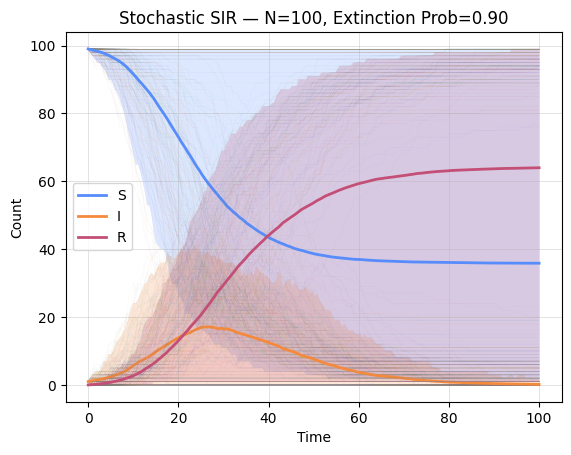

In [10]:
# Small population: some replicates will have early extinction
model_small = SIR()
model_small(
    inits=[99, 1, 0],
    trange=[0, 100],
    totpop=100,
    params={'beta': 0.3, 'gamma': 0.1},
    reps=200,
    seed=42,
    n_points=200,
)

stats_small = model_small.summary()
print(f"Population: 100")
print(f"R0: {model_small.R0}")
print(f"Extinction probability: {stats_small['extinction_probability']:.2f}")
print(f"Peak I median: {stats_small['peak_I_median']}")

model_small.plot_traces(show_reps=True, alpha=0.05, show_ci=True)
plt.title(f'Stochastic SIR — N=100, Extinction Prob={stats_small["extinction_probability"]:.2f}')
plt.show()

## 8. Other Stochastic Models

The same API applies to all CTMC models. Here are quick examples of SIS, SIRS, and SEIR.

### SIS Model

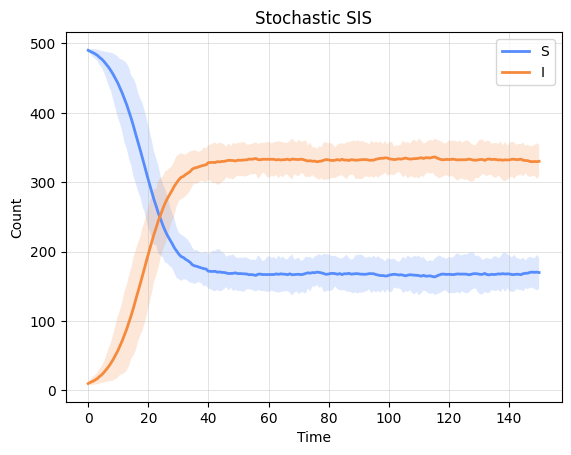

In [11]:
sis = SIS()
sis(
    inits=[490, 10],
    trange=[0, 150],
    totpop=500,
    params={'beta': 0.3, 'gamma': 0.1},
    reps=100,
    seed=42,
    n_points=200,
)
sis.plot_traces(show_ci=True)
plt.title('Stochastic SIS')
plt.show()

### SIRS Model

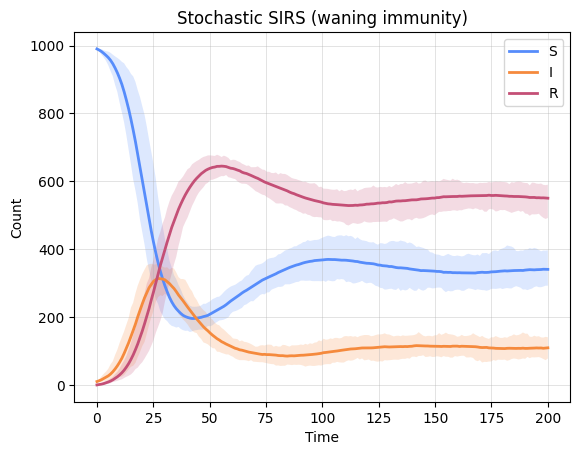

In [12]:
sirs = SIRS()
sirs(
    inits=[990, 10, 0],
    trange=[0, 200],
    totpop=1000,
    params={'beta': 0.3, 'gamma': 0.1, 'xi': 0.02},
    reps=100,
    seed=42,
    n_points=200,
)
sirs.plot_traces(show_ci=True)
plt.title('Stochastic SIRS (waning immunity)')
plt.show()

### SEIR Model

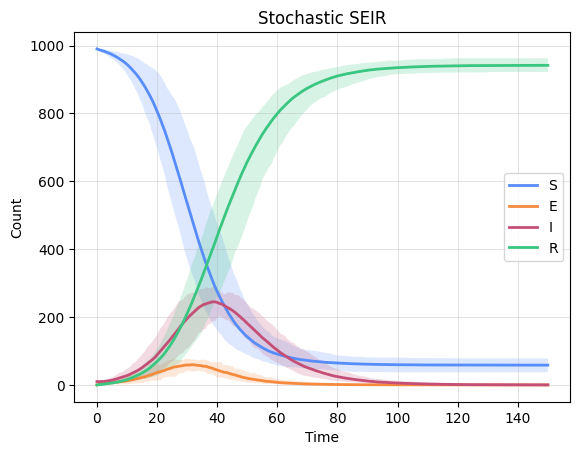

In [13]:
seir = SEIR()
seir(
    inits=[990, 0, 10, 0],
    trange=[0, 150],
    totpop=1000,
    params={'beta': 0.3, 'gamma': 0.1, 'epsilon': 0.5},
    reps=100,
    seed=42,
    n_points=200,
)
seir.plot_traces(show_ci=True)
plt.title('Stochastic SEIR')
plt.show()

## 9. Exporting Results

Export results to a pandas DataFrame, specifying a replicate or using the mean.

In [14]:
# Mean trajectory as DataFrame
df_mean = model.to_dataframe()
print('Mean trajectory:')
print(df_mean.head())

# Specific replicate
df_rep0 = model.to_dataframe(replicate=0)
print(f'\nReplicate 0 (shape: {df_rep0.shape}):')
print(df_rep0.head())

Mean trajectory:
       time        S       I     R
0  0.000000  990.000  10.000  0.00
1  0.502513  988.395  10.965  0.64
2  1.005025  986.590  12.170  1.24
3  1.507538  984.635  13.465  1.90
4  2.010050  982.380  14.920  2.70

Replicate 0 (shape: (200, 4)):
       time      S     I    R
0  0.000000  990.0  10.0  0.0
1  0.502513  990.0  10.0  0.0
2  1.005025  989.0  11.0  0.0
3  1.507538  988.0  10.0  2.0
4  2.010050  987.0   9.0  4.0


## 10. Reproducibility

Using the `seed` parameter ensures reproducible results, which is essential for debugging and sharing analyses.

In [15]:
# Two runs with same seed produce identical results
m1 = SIR()
m1([990, 10, 0], [0, 50], 1000, {'beta': 0.3, 'gamma': 0.1}, reps=10, seed=999)

m2 = SIR()
m2([990, 10, 0], [0, 50], 1000, {'beta': 0.3, 'gamma': 0.1}, reps=10, seed=999)

print('Reproducible:', np.array_equal(m1.traces['I'], m2.traces['I']))

Reproducible: True


## 11. Model Properties

Like deterministic models, stochastic models expose `R0`, `diagram`, and other properties.

In [21]:
model = SIR()
model([990, 10, 0], [0, 50], 1000, {'beta': 0.3, 'gamma': 0.1}, reps=1, seed=42)

print(f'R0 = {model.R0}')
print(f'Model type: {model.model_type}')
print(f'State variables: {list(model.state_variables.keys())}')
print(f'Events: {list(model.events.keys())}')

R0 = 2.9999999999999996
Model type: SIR CTMC
State variables: ['S', 'I', 'R']
Events: ['infection', 'recovery']


In [20]:
md(model.diagram)

flowchart LR
        S(Susceptible) -->|$$\beta$$| I(Infectious)
        I -->|$$\gamma$$| R(Removed)
        